## Modelo K-means

Imports e setup

In [11]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# garantir import do pacote src
sys.path.append("..")

from src import config
from src import data_io
from src.clustering_kmeans import (
    KMeansConfig,
    sanity_check_scaled,
    compute_elbow_inertia,
    compute_silhouette,
    fit_kmeans,
    make_cluster_profile,
    plot_elbow,
    plot_silhouette,
    save_current_figure,
) 

Seleção do dataset

In [12]:
DATASET_NAME = "full"  # opções: "full", "risk", "credit", "consumption"

dataset_map = {
    "full": "creditcard_full_zscore.csv",
    "risk": "creditcard_risk_zscore.csv",
    "credit": "creditcard_credit_behavior_zscore.csv",
    "consumption": "creditcard_consumption_zscore.csv",
}

processed_path = Path(config.PROCESSED_DIR) / dataset_map[DATASET_NAME]
processed_path

WindowsPath('../data/processed/creditcard_full_zscore.csv')

Load do dataset processado

In [13]:
df = data_io.load_raw(str(processed_path))  # serve para processed também (é um read_csv)
df.shape, df.head()

((8950, 17),
     BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
 0 -1.205218          -0.249434  -0.113532         -0.987090   
 1  0.948918           0.134325  -1.679855         -0.987090   
 2  0.824993           0.518084   0.600727          1.062022   
 3  0.624653          -1.016953   0.827499          1.265778   
 4  0.271260           0.518084  -0.708481         -0.114307   
 
    INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
 0                0.394480     -0.930733            -0.806490   
 1               -1.087454      1.528788            -1.221758   
 2               -1.087454     -0.930733             1.269843   
 3               -1.087454      0.564372            -1.014125   
 4               -1.087454     -0.930733            -1.014125   
 
    ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
 0                   -0.678661                         -0.707313   
 1                   -0.678661                         -0.916995   
 2   

Sanity check

In [14]:
check = sanity_check_scaled(df)
check

{'mean_abs_mean': 1.2403559028451042e-16,
 'mean_abs_std_minus_1': 5.587060372548499e-05,
 'ok_mean': True,
 'ok_std': True}

Definir range de K e calcular Elbow + plot + salvar figura

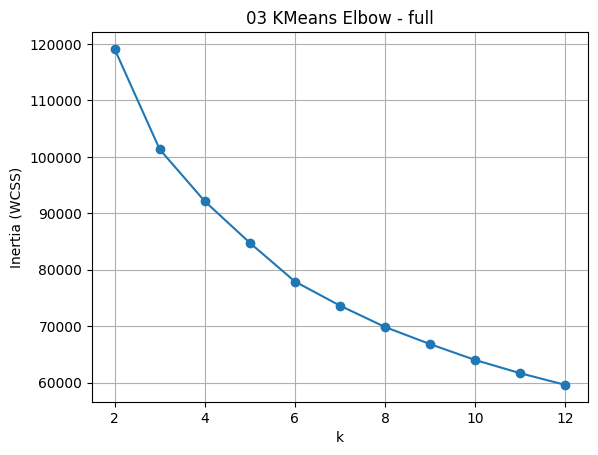

<Figure size 640x480 with 0 Axes>

In [15]:
km_cfg = KMeansConfig(
    k_min=2,
    k_max=12,
    random_state=config.RANDOM_STATE,
    n_init=10
)

k_values = range(km_cfg.k_min, km_cfg.k_max + 1)

elbow_df = compute_elbow_inertia(
    df,
    k_values=k_values,
    random_state=km_cfg.random_state,
    init=km_cfg.init,
    n_init=km_cfg.n_init,
    max_iter=km_cfg.max_iter,
)

plot_elbow(elbow_df, title=f"03 KMeans Elbow - {DATASET_NAME}")

# salvar figura (reports/figures)
fig_path = Path("../reports/figures") / f"03_KMEANS_elbow_{DATASET_NAME}.png"
save_current_figure(fig_path)

Silhouette + plot + salvar figura

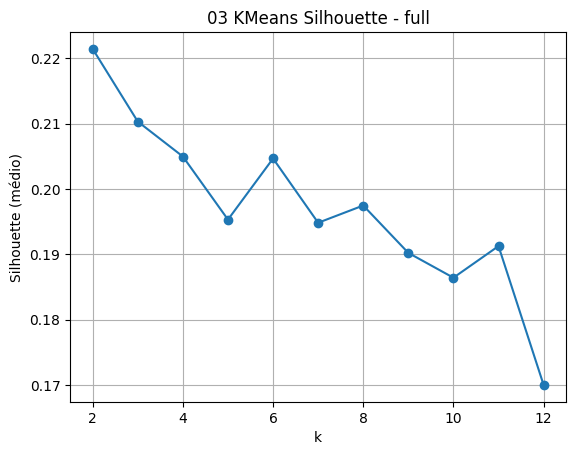

,k,silhouette
0,2,0.221413
1,3,0.210300
2,4,0.204955
4,6,0.204653
6,8,0.197463
3,5,0.195307
5,7,0.194824
9,11,0.191256
7,9,0.190215
8,10,0.186417


<Figure size 640x480 with 0 Axes>

In [16]:
sil_df = compute_silhouette(
    df,
    k_values=k_values,
    random_state=km_cfg.random_state,
    init=km_cfg.init,
    n_init=km_cfg.n_init,
    max_iter=km_cfg.max_iter,
)

plot_silhouette(sil_df, title=f"03 KMeans Silhouette - {DATASET_NAME}")

fig_path = Path("../reports/figures") / f"03_KMEANS_silhouette_{DATASET_NAME}.png"
save_current_figure(fig_path)

sil_df.sort_values("silhouette", ascending=False).head(10)

Escolher K final e treinar

In [7]:
# K_FINAL = int(sil_df.sort_values("silhouette", ascending=False).iloc[0]["k"]) Matematicamente falando seria correto ter essa função, mas partindo da visão de negócio não faz sentido apenas 2 clusters

# escolha guiada por negócio
K_FINAL = 4

forçar interpretabilidade

In [8]:
model, labels = fit_kmeans(
    df,
    n_clusters=K_FINAL,
    random_state=km_cfg.random_state,
    init=km_cfg.init,
    n_init=km_cfg.n_init,
    max_iter=km_cfg.max_iter,
)

df_with_cluster = df.copy()
df_with_cluster["cluster_kmeans"] = labels
df_with_cluster["cluster_kmeans"].value_counts().sort_index()

cluster_kmeans
0    2281
1    3011
2    2194
3    1464
Name: count, dtype: int64

Perfil dos clusters (tabela de interpretação)

In [9]:
profile_mean = make_cluster_profile(df, labels, cluster_col="cluster_kmeans", agg="mean")
profile_mean

,cluster_kmeans,cluster_size,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,0,2281,0.423355,0.426773,0.909604,1.157393,0.597472,-0.211881,0.908366,1.337827,0.504640,-0.175998,-0.107321,0.971528,0.585496,0.575263,0.275878,0.141926,0.235866
1,1,3011,0.628952,0.296772,-0.982429,-0.469462,-0.897263,0.915223,-0.984207,-0.483054,-0.826134,0.777817,0.565742,-0.522356,-0.006416,0.111625,0.450780,-0.429191,-0.068159
2,2,2194,-0.371857,0.281989,0.439644,-0.515595,0.865938,-0.624524,0.770896,-0.513006,0.958360,-0.514061,-0.389310,-0.009909,-0.430739,-0.176957,-0.246664,0.364597,-0.023499
3,3,1464,-1.395895,-1.697904,-0.055527,-0.065060,-0.383226,-0.616276,-0.546367,-0.322113,-0.523385,-0.555127,-0.412911,-0.424523,-0.253522,-0.860678,-0.987292,0.115186,-0.192095


Persistir outputs

In [10]:
# salvar tabela de perfil
out_profile = Path("../reports") / f"kmeans_profile_mean_{DATASET_NAME}.csv"
profile_mean.to_csv(out_profile, index=False)

# salvar dataset com cluster (opcional, mas útil p/ 05_interpretacao_segmentos)
out_clustered = Path(config.PROCESSED_DIR) / f"{DATASET_NAME}_with_kmeans_clusters.csv"
df_with_cluster.to_csv(out_clustered, index=False)

out_profile, out_clustered

(WindowsPath('../reports/kmeans_profile_mean_full.csv'),
 WindowsPath('../data/processed/full_with_kmeans_clusters.csv'))